## Imports

In [1]:
"""
Initial imports and function declarations
"""

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm.notebook import tqdm, trange
import firedrake as fd
from firedrake import (
    eq,
    conditional,
    min_value,
    max_value,
    exp,
    sqrt,
    inner,
    sym,
    tr,
    grad,
    Constant,
    dx,
    ds,
    dS,
    avg,
    jump,
)
import irksome
from irksome import Dt, lag
from icepack.constants import (
    weertman_sliding_law,
    glen_flow_law,
    gravity as g,
    ice_density as ρ_I,
    water_density as ρ_W,
)

import ufl

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


## Definition of Laws

In [2]:
def get_test_function(q):
    z, = ufl.algorithms.extract_coefficients(q)
    w = fd.TestFunction(z.function_space())
    return fd.replace(q, {z: w})


# redundant, use the imports instead
n = 3 #Constant(glen_flow_law)
m = 3 #Constant(weertman_sliding_law)

# fields are mutable state?
# parameters are immutable?
# This uses the global variable s, which is mutable. Should it be part of fields?
def friction_law(**kwargs):
    τ, u, h = map(kwargs.get, ("basal_stress", "velocity", "thickness"))

    parameters = ("sliding_coefficient", "sliding_exponent")
    K, m = map(kwargs.get, parameters)

    p_W = lag(ρ_W * g * max_value(0, -(s - h)))
    p_I = ρ_I * g * h
    r = Constant(0.99)
    ϕ = lag(conditional(p_W > r * p_I, 0, 1))

    σ = get_test_function(τ)
    τ_2 = inner(τ, τ)

    if m == 1:
        τ_m = Constant(1.0)
    elif m == 3:
        τ_m = τ_2
    elif m == 5:
        τ_m = τ_2 ** 2
    else:
        raise ValueError("Sliding law exponent must be in [1, 3, 5]!")

    f = ϕ if m == 1 else ϕ ** m
    return inner(K * τ_m * τ + f * u, σ) * dx


def flow_law(**kwargs):
    variables = ("velocity", "membrane_stress", "thickness")
    u, M, h = map(kwargs.get, variables)
    parameters = ("flow_law_coefficient", "flow_law_exponent")
    A, n = map(kwargs.get, parameters)

    N = get_test_function(M)
    d = mesh.geometric_dimension
    M_2 = (inner(M, M) - tr(M)**2 / (d + 1)) / 2

    if n == 1:
        M_n = Constant(1.0)
    elif n == 3:
        M_n = M_2
    elif n == 5:
        M_n = M_2 ** 2
    else:
        raise ValueError("Flow law exponent must be in [1, 3, 5]!")

    ε = sym(grad(u))
    return h * (A * M_n * (inner(M, N) - tr(M) * tr(N) / (d + 1)) - inner(ε, N)) * dx


def momentum_balance(**kwargs):
    variables = (
        "velocity", "membrane_stress", "basal_stress", "thickness", "surface"
    )
    u, M, τ, h, s = map(kwargs.get, variables)
    v = get_test_function(u)

    ε = sym(grad(v))
    cell_balance = (-h * inner(M, ε) + inner(τ - ρ_I * g * h * grad(s), v)) * dx

    ν = fd.FacetNormal(mesh)
    facet_balance = ρ_I * g * avg(h) * inner(jump(s, ν), avg(v)) * dS

    return cell_balance + facet_balance


def terminus(**kwargs):
    variables = ("velocity", "thickness", "surface", "terminus_ids")
    u, h, s, terminus_ids = map(kwargs.get, variables)
    v = get_test_function(u)

    d = fd.min_value(s - h, 0)
    τ_I = ρ_I * g * h**2 / 2
    τ_W = ρ_W * g * d**2 / 2

    ν = fd.FacetNormal(mesh)
    return (τ_I - τ_W) * inner(v, ν) * ds(terminus_ids)


def smooth_max(a, b, ϵ):
    return (a + b + ((a - b)**2 + ϵ**2) ** 0.5) / 2

def mass_balance(**kwargs):
    variables = ("thickness", "velocity", "accumulation", "thickness_in")
    h, u, a, h_in = map(kwargs.get, variables)
    η = get_test_function(h)

    ν = fd.FacetNormal(mesh)
    F_cells = (Dt(h) * η - inner(h * u, grad(η)) - a * η) * dx
    f = h * max_value(0, inner(u, ν))
    F_facets = jump(f) * jump(η) * dS
    F_outflow = f * η * ds
    F_inflow = h_in * min_value(0, inner(u, ν)) * η * ds
    return F_cells + F_facets + F_outflow + F_inflow

## Loading the Steady State

In [3]:
# load steady state data
with fd.CheckpointFile('mismip-steady-state.h5', "r") as chk:
    mesh = chk.load_mesh("mesh")
    b = chk.load_function(mesh, name="bed")
    w = chk.load_function(mesh, name="mono")

In [4]:
u, M, τ, h = w.subfunctions

## Initialization and setting of values

In [ ]:
lx = 610e3
nx = mesh.num_cells()

thickness_element = fd.FiniteElement("DG", "interval", 0)
bed_element = fd.FiniteElement("CG", "interval", 1)
degree = 1

velocity_element = fd.FiniteElement("CG", "interval", degree)
stress_element = fd.FiniteElement("DG", "interval", degree - 1)

Q = fd.FunctionSpace(mesh, thickness_element)
S = fd.FunctionSpace(mesh, bed_element)
V = fd.VectorFunctionSpace(mesh, velocity_element)
Σ = fd.TensorFunctionSpace(mesh, stress_element, symmetry=True)

W = V * Σ * V * Q

Lx = Constant(lx)

In [6]:
s = fd.Function(Q).interpolate(max_value(b + h, (1 - ρ_I / ρ_W) * h))
z_b = fd.Function(Q).interpolate(s - h)

In [7]:
x = fd.SpatialCoordinate(mesh)[0]

h_in = Constant(200.0)

δu = fd.Constant(90.0)
expr = fd.as_vector([δu * x / Lx])  # 1-component vector
u_0 = fd.Function(V).interpolate(expr)

del δu
del expr

In [8]:
A = Constant(20)
K = Constant(1e6)

τ_c = Constant(0.01)
ε_c = Constant(A * τ_c ** n)
u_c = Constant(K * τ_c ** m)

del A
del K

In [9]:
"""
Initialization of function spaces and mass/momentum balance
"""

inflow_ids = (1,)
terminus_ids = (2,)

# # #s = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
# # s = max_value(b + h, (1 - ρ_I / ρ_W) * h)

# Mutable State (partially derived from z?)?
parameters_1 = {
    "flow_law_coefficient": ε_c / τ_c,
    "flow_law_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
    "sliding_exponent": 1,
}

parameters_3 = {
    "flow_law_coefficient": ε_c / τ_c ** n,
    "flow_law_exponent": n,
    "sliding_coefficient": u_c / τ_c ** m,
    "sliding_exponent": m,
}

α = Constant(1e-3)

In [10]:
inflow_bc = fd.DirichletBC(W.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

u, M, τ, h = fd.split(w)
v, N, σ, η = fd.TestFunctions(W)

s = lag(max_value(b + h, (1 - ρ_I / ρ_W) * h))
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

h_min = Constant(1e-3)
regularized = {"thickness": max_value(h_min, h)}

H = Constant(500.0)

F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F_momentum = F_flow_law + F_sliding_law + F_balance + F_terminus

In [11]:
F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**(fields | regularized))
F_terminus = terminus(**(fields | regularized), terminus_ids=terminus_ids)

F_momentum_regularized = F_flow_law + F_sliding_law + F_balance + F_terminus

In [12]:
a_0 = Constant(1.0)
m_0 = Constant(1.125)

z_b = s - h

heaviside = lambda z: 1 / (1 + fd.exp(-z))

a_expr = a_0 - m_0 * heaviside(z_b - b)

del a_0
del m_0

In [13]:
F_mass = mass_balance(
    thickness=h, velocity=u, accumulation=lag(a_expr), thickness_in=h
)
F = F_momentum + F_mass
Fp = F_momentum_regularized + F_mass

## Analysis Tools

### Determining the Terminus

For calving events we need to know where the terminus is to be able to determine where the new terminus should be after the calving has occurred. 
In most cases, and assumed in my approach so far, the terminus is just the first point where the thickness function is zero. 
1. The first function I have defined finds this spot by creating a vertex only mesh for each integer value along the flow line (so for every meter) and then using np.where() to find the first value where it is zero. This is numerically quite expensive. 
A bit of a speed-up is achieved by making the spacing of the mesh larger, though for this to work one needs to multiply the result by the spacing that was used (since np.where returns the value's spot in the list of not its coordinates).
2. Another option is to access the values of the function at the nodes of the mesh using '.dat.data_ro'. This is an attribute of the function and is therefore quite fast.
The problem with this approach is that there are only 450 intervals, so the step sizes are about 1335 which means the actual terminus position can be up to 1.3 km further to the left.
This one is the winner because the thickness is constant on each element anyway.
3. The next option would be to combine these two approaches. This would mean first finding the interval in which the terminus lies and then using creating a finer vertex only mesh on that interval to find the exact position. It turns out this is actually way too intense and the whole kernel crashes when I attempt to do this.

In [ ]:
def end_of_glacier_slow(f, accuracy=1):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_init_values = f.dat.data_ro # a faster but less data point way to access the values of f
    if f_init_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    f_mesh = fd.Function(f).ufl_domain()
    points = np.arange(0, 610_000, accuracy)[:, None] # list of lists (requirement for the vertex only mesh)
    vom = fd.VertexOnlyMesh(f_mesh, points)
    P = fd.FunctionSpace(vom, "DG", 0)
    f_at_points = fd.assemble(fd.interpolate(f, P)) 
    f_values = f_at_points.dat.data_ro

    # if f_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
    #     return 'empty'
    zeros = np.where(f_values==0)[0]

    return zeros[0]*accuracy # this gives us the first point at which the thickness is zero

In [ ]:
def end_of_glacier_fast(f):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_values = f.dat.data_ro
    n = len(f_values)

    f_mesh = fd.Function(f).ufl_domain()
    length = fd.assemble(Constant(1.0) * dx(domain=f_mesh))

    # print(f_values)
    zeros = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]
    # print(zeros)

    if len(zeros) == 0: # if this is the case then the terminus lies outside our domain
        return 'empty'
    # gives us the first point at which the thickness is zero (length/n gives us the length of each element)
    return int(zeros[0]*(length/n))

In [ ]:
def end_of_glacier_node(f, elements=nx):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first node (of the mesh) where f is zero.
    """
    f_values = f.dat.data_ro # if hasattr(f, "dat") else fd.Function(f).dat.data_ro
    n = len(f_values)
    
    # print(f_values)
    zeros = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]
    # print(zeros)

    if len(zeros) == 0: # if this is the case then the terminus lies outside our domain
        return 'empty'
    # n/elements makes sure that we still end up getting the node even if we have more data than nodes
    return int(zeros[0]/(n/elements)) 

### Miscellaneous Tools

In [ ]:
def glacier_over_time(term_list, property):
    """
    This function takes a list of values and then creates an x-axis that 
    enumerates the points. In this context this is useful for plottting a property 
    that we are tracking over time (so for each time step).
    """
    n = len(term_list)
    x_list = np.arange(n)
    _, ax = plt.subplots()
    ax.set_title(f"{property} over Time")
    ax.set_xlabel("Timesteps (month)")
    ax.set_ylabel(f"{property}")
    plt.grid()
    # ax.set_ylim(100_000, 600_000)
    return ax.plot(x_list, term_list)

The following function is used to find the volume of the glacier.

In [ ]:
def integrate(func):
    """
    Returns the integral of a function
    """
    return fd.assemble(func* dx)

## Calving Time Stepper

In [19]:
"""
Main driver:
"""

method = irksome.BackwardEuler()
t = Constant(0.0)
timestep = 1/12
dt = Constant(timestep)

fparams = {"quadrature_degree": 8}
sparams = {
    "snes_monitor": ":mismip-dual-ts.log",
    "snes_type": "vinewtonrsls",
    "snes_linesearch_type": "bt", 
    "snes_linesearch_max_it": 200,
    "snes_max_it": 1000,
    "snes_atol": 2e-8,
    "snes_rtol": 1e-4,
    "pc_factor_mat_solver_type": "mumps",
}
lower = fd.Function(W)
upper = fd.Function(W)
lower.assign(-np.inf)
lower.sub(3).assign(0.0)
upper.assign(+np.inf)

params = {
    "bcs": bcs,
    "form_compiler_parameters": fparams,
    "solver_parameters": sparams,
    "stage_type": "value",
    "basis_type": "Bernstein",
    "bounds": ("stage", lower, upper)
}

In [20]:
solver = irksome.TimeStepper(F, method, t, dt, w, **params, Jp=Fp)

final_time = 3000
num_steps = int(final_time / timestep)

ws = [w.copy(deepcopy=True)]

for step in trange(num_steps):
    h = w.sub(3)
    x = fd.SpatialCoordinate(fd.Function(h).ufl_domain())[0]

    f = fd.Function(Q)

    h_values = h.dat.data_ro
    small_thickness_node = np.where(h_values<=100)[0][0]
    expr = h * fd.conditional(fd.le(x, small_thickness_node * (lx/nx)), 1.0, 0.0)
    f.interpolate(expr)
    w.sub(3).assign(f)
     
    solver.advance()
    ws.append(w.copy(deepcopy=True))

  0%|          | 0/36000 [00:00<?, ?it/s]

## Plotting and Analyzing Results

In [21]:
u, M, τ, h = w.subfunctions

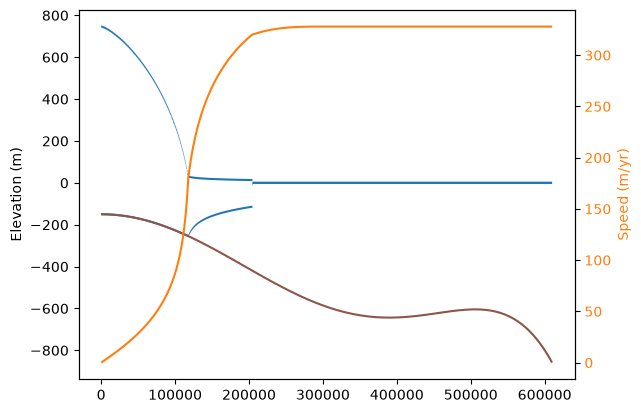

In [22]:
s = fd.Function(Q).interpolate(max_value(b + h, (1 - ρ_I / ρ_W) * h))
z_b = fd.Function(Q).interpolate(s - h)

fig, ax = plt.subplots()
ax.set_ylabel("Elevation (m)")
fd.plot(s, edgecolor="tab:blue", axes=ax)
fd.plot(z_b, edgecolor="tab:blue", axes=ax)
fd.plot(b, edgecolor="tab:brown", axes=ax)

ax = ax.twinx()
ax.set_ylabel("Speed (m/yr)", color="tab:orange")
ax.tick_params(axis="y", labelcolor="tab:orange")
u_x = fd.Function(S).interpolate(u[0])
fd.plot(u_x, edgecolor="tab:orange", axes=ax);

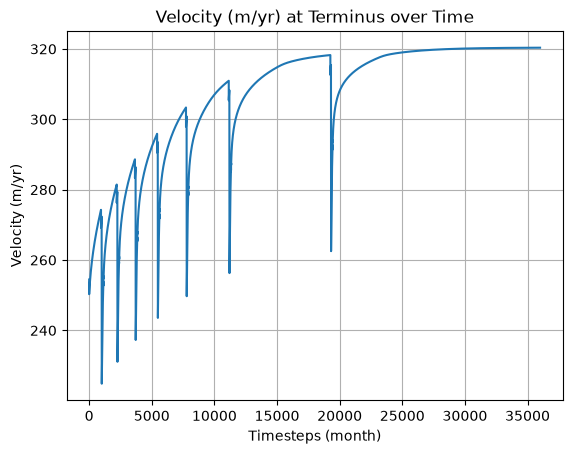

In [ ]:
# this plot shows the velocity at approximatley the terminus of the glacier
terminus_velocities = []
for w in ws:
    u = w.sub(0)
    h1 = w.sub(3)
    node = end_of_glacier_node(h1)
    u_at_points = u.dat.data_ro

    if node == 'empty':
        terminus_velocities += [u_at_points[-1]]
    else:
        terminus_velocities += [u_at_points[node]]

glacier_over_time(terminus_velocities, "Velocity (m/yr) at Terminus");

[np.float64(327.9059980925065), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float64(320.34782971952706), np.float

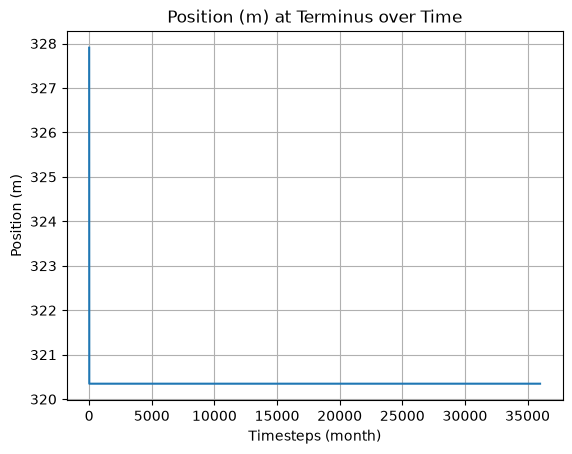

In [ ]:
terminus_positions = []
for w in ws:
    h1 = w.sub(3)
    node = end_of_glacier_node(h1)
    u_at_points = u.dat.data_ro

    if node == 'empty':
        terminus_positions = terminus_positions
    else:
        terminus_positions += [u_at_points[node]]

print(terminus_positions)

glacier_over_time(terminus_positions, "Position (m) of Terminus");

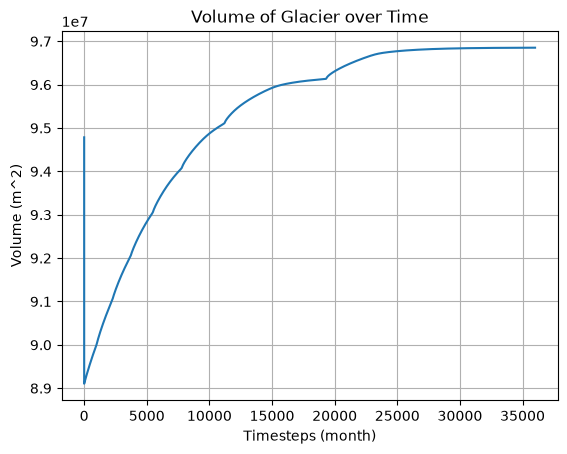

In [ ]:
volume_list = []
for w in ws:
    h = w.sub(3)
    volume_list += [integrate(h)]

n = len(volume_list)
x_list = np.arange(n)
_, ax = plt.subplots()
ax.set_title(f"Volume of Glacier over Time")
ax.set_xlabel("Timesteps (month)")
ax.set_ylabel(f"Volume (m^2)")
plt.grid()
ax.plot(x_list, volume_list);